In [1]:
!pip install shap

In [4]:
import numpy as np
import pandas as pd
import tensorflow as tf
import kagglehub
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap



In [5]:
# Download latest version
path = kagglehub.dataset_download("soroushsaadat81/parkinsons-telemonitoring")

print("Path to dataset files:", path)

100%|██████████| 292k/292k [00:00<00:00, 64.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/soroushsaadat81/parkinsons-telemonitoring/versions/1


In [6]:
file = os.path.join(path, "parkinsons_updrs.data")

df = pd.read_csv(file)

#exibir
df.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [7]:
features = [
    'age',
    'sex',
    'test_time',
    'Jitter(%)',
    'Jitter(Abs)',
    'Jitter:RAP',
    'Jitter:PPQ5',
    'Jitter:DDP',
    'Shimmer',
    'Shimmer(dB)',
    'Shimmer:APQ3',
    'Shimmer:APQ5',
    'Shimmer:APQ11',
    'Shimmer:DDA',
    'NHR',
    'HNR',
    'RPDE',
    'DFA',
    'PPE'
]

X = df[features]
y = df['motor_UPDRS']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse',  metrics=['mae'])

In [12]:
history = model.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 271.4226 - mae: 13.7657 - val_loss: 85.7616 - val_mae: 7.5997
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 75.5551 - mae: 7.0788 - val_loss: 63.5055 - val_mae: 6.6096
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.9734 - mae: 6.5047 - val_loss: 55.4735 - val_mae: 6.2041
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.1660 - mae: 6.1831 - val_loss: 53.0989 - val_mae: 6.1691
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 52.8672 - mae: 6.0360 - val_loss: 48.6417 - val_mae: 5.8066
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 49.7023 - mae: 5.8414 - val_loss: 48.7428 - val_mae: 5.7074
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 46.9050 - mae: 5.6893 - val_loss: 44.0394 - val_mae: 5.5231
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 44.0605 - mae: 5.4756 - val_loss: 41.8602 - val_mae: 5.4006
Epoch 9/100
118/118 ━━━━━━━━━━

In [13]:
y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
MAE: 3.0319
MSE: 18.3545
RMSE: 4.2842
R²: 0.7124


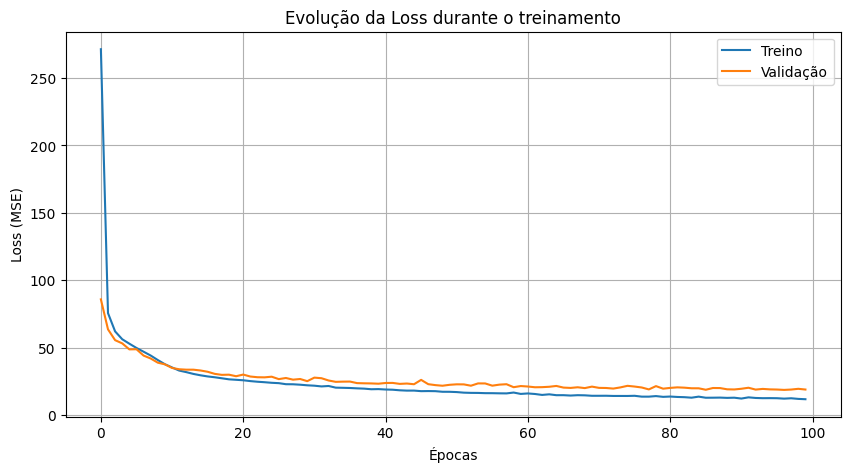

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')

plt.xlabel('Épocas')
plt.ylabel('Loss (MSE)')
plt.title('Evolução da Loss durante o treinamento')
plt.legend()
plt.grid()

plt.show()

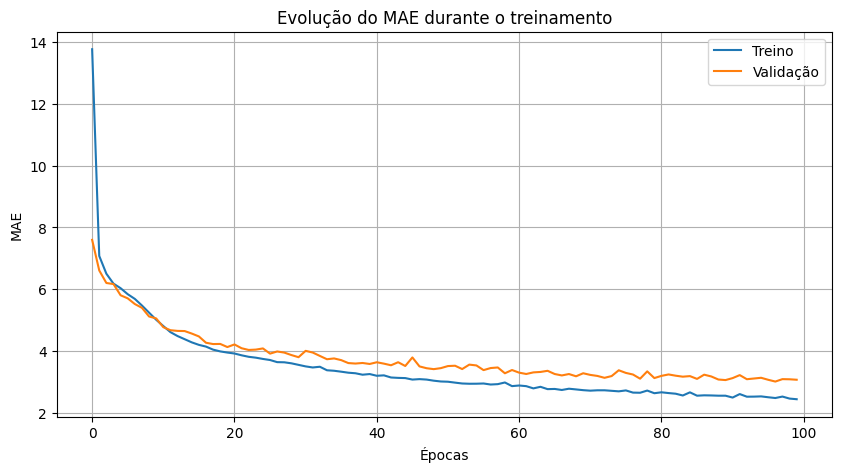

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['mae'], label='Treino')
plt.plot(history.history['val_mae'], label='Validação')

plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.title('Evolução do MAE durante o treinamento')
plt.legend()
plt.grid()

plt.show()

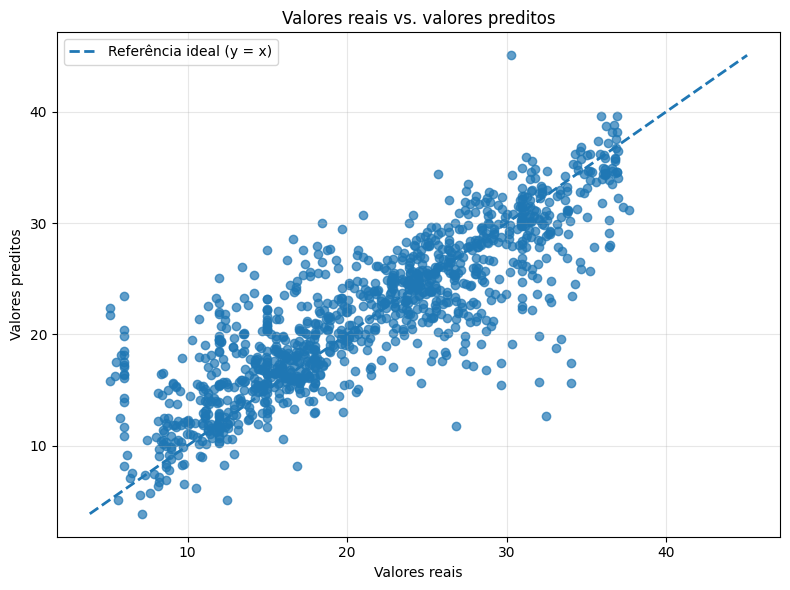

In [16]:
plt.figure(figsize=(8, 6))

# Valores reais x valores preditos
plt.scatter(y_test, y_pred, alpha=0.7)

# Linha de referência ideal: y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Referência ideal (y = x)'
)

plt.xlabel('Valores reais')
plt.ylabel('Valores preditos')
plt.title('Valores reais vs. valores preditos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
model.save('parkinsons_model.keras')
print('Model saved.')

Model saved.


In [18]:
indice = 0

valor_real = y_test.iloc[indice]

valor_previsto = y_pred[indice]

print("Valor real:", valor_real)
print("Valor previsto:", valor_previsto)
print("Erro:", abs(valor_real - valor_previsto))

Valor real: 33.084
Valor previsto: 18.752071
Erro: 14.331928619384769


In [19]:
resultados = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': y_pred
})

resultados['Erro'] = abs(resultados['Real'] - resultados['Previsto'])

print(resultados.head(10))

      Real   Previsto       Erro
0  33.0840  18.752071  14.331929
1   7.1599   3.870386   3.289514
2  11.2180  13.944765   2.726765
3  12.7590  10.621243   2.137757
4  25.3910  21.476406   3.914594
5  18.0000  17.701445   0.298555
6  11.4840  16.309612   4.825612
7  25.2360  29.682497   4.446497
8  17.9280  12.948372   4.979628
9  28.0920  26.867512   1.224488


In [29]:
# Criando o explicador SHAP
explainer = shap.Explainer(model, X_train)

# Calculando os valores SHAP para os dados de teste
shap_values = explainer(X_test)

PermutationExplainer explainer: 1176it [03:09,  5.84it/s]


/tmp/ipykernel_2680/1571396283.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


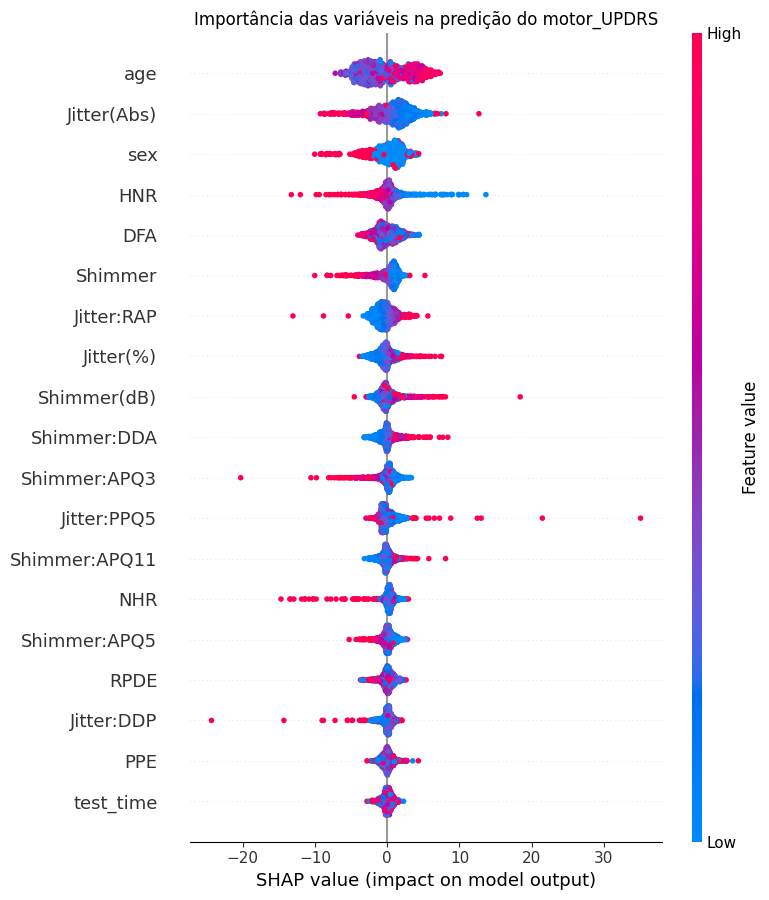

In [37]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=features,
    show=False
)

plt.title('Importância das variáveis na predição do motor_UPDRS')

plt.tight_layout()

plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')

plt.show()

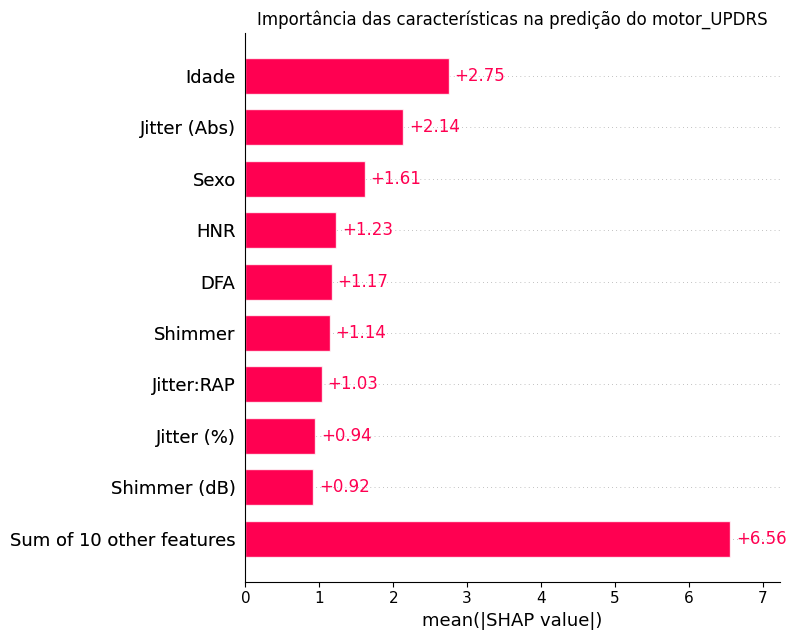

In [33]:
nomes_portugues = [
    'Idade',
    'Sexo',
    'Tempo de teste',
    'Jitter (%)',
    'Jitter (Abs)',
    'Jitter:RAP',
    'Jitter:PPQ5',
    'Jitter:DDP',
    'Shimmer',
    'Shimmer (dB)',
    'Shimmer:APQ3',
    'Shimmer:APQ5',
    'Shimmer:APQ11',
    'Shimmer:DDA',
    'NHR',
    'HNR',
    'RPDE',
    'DFA',
    'PPE'
]

# Substitui os nomes das features no SHAP
shap_values.feature_names = nomes_portugues

# Gera o gráfico de importância
shap.plots.bar(shap_values, show=False)

plt.title('Importância das características na predição do motor_UPDRS')
plt.tight_layout()
plt.savefig('shap_importancia.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2680/2823357860.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


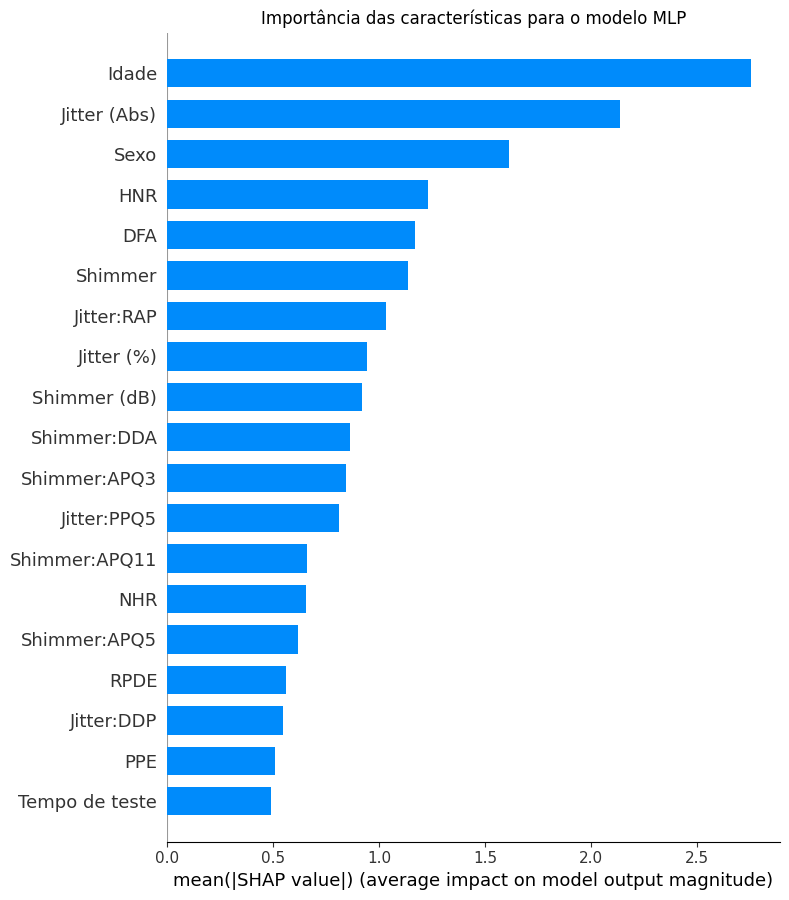

In [34]:
# Gráfico de importância das características

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=nomes_portugues,
    plot_type='bar',
    show=False
)

plt.title('Importância das características para o modelo MLP')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()